# 1. Frame the problem
Using the customer description, Define the problem your trying to solve in your own words (remember this is not technial but must be specific so the customer understands the project

Customer needs a model that can predict whether a given email will be SPAM (trivial) or HAM 😋 (important)

# 2. Get the Data 
Define how you recieved the data (provided, gathered..)

In [ ]:
Data has been given to us by the boss/customer through a google drive link

# 3. Explore the Data
Gain insights into the data you have from step 2, making sure to identify any bias

Total files: 873
SPAM messages: 391
HAM messages: 481
SPAM ratio: 44.79%


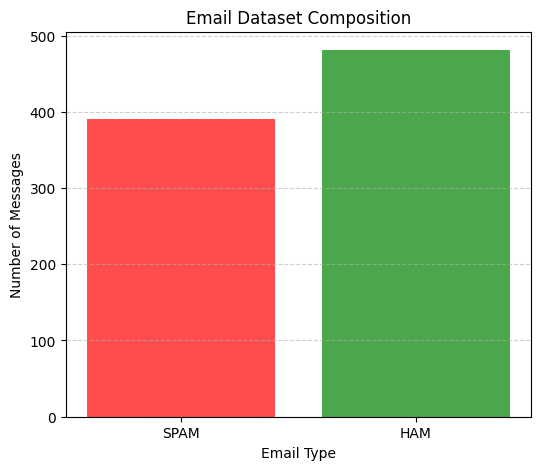

In [2]:
import os
import matplotlib.pyplot as plt
import pandas as pd

data_dir = "data"

files = os.listdir(data_dir)

spam_files = [f for f in files if f.lower().startswith("spmsg")]
ham_files = [f for f in files if f[0].isdigit()]

spam_count = len(spam_files)
ham_count = len(ham_files)

df = pd.DataFrame({
    "Category": ["SPAM", "HAM"],
    "Count": [spam_count, ham_count]
})

print("Total files:", len(files))
print("SPAM messages:", spam_count)
print("HAM messages:", ham_count)
print(f"SPAM ratio: {spam_count / len(files):.2%}")

plt.figure(figsize=(6,5))
plt.bar(df["Category"], df["Count"], color=["red", "green"], alpha=0.7)
plt.title("Email Dataset Composition")
plt.ylabel("Number of Messages")
plt.xlabel("Email Type")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Avg SPAM length: 2867.2 chars
Avg HAM length: 2450.9 chars


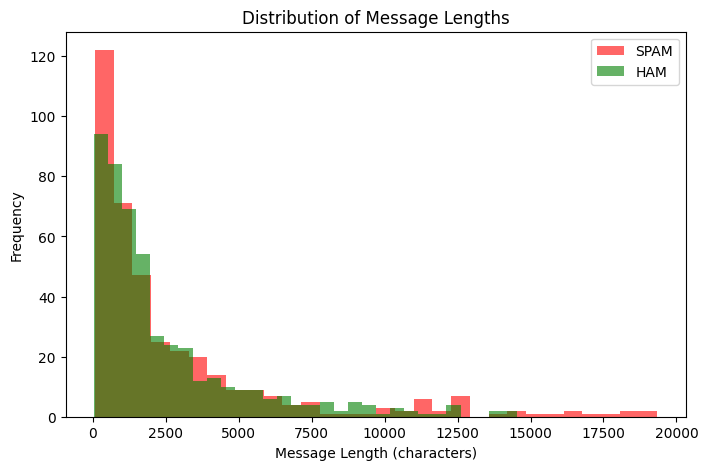

In [3]:
def read_file(filepath):
    with open(filepath, encoding="latin-1") as f:
        return f.read()

spam_lengths = [len(read_file(os.path.join(data_dir, f))) for f in spam_files]
ham_lengths = [len(read_file(os.path.join(data_dir, f))) for f in ham_files]

print(f"Avg SPAM length: {sum(spam_lengths)/len(spam_lengths):.1f} chars")
print(f"Avg HAM length: {sum(ham_lengths)/len(ham_lengths):.1f} chars")

plt.figure(figsize=(8,5))
plt.hist(spam_lengths, bins=30, alpha=0.6, color='red', label='SPAM')
plt.hist(ham_lengths, bins=30, alpha=0.6, color='green', label='HAM')
plt.title("Distribution of Message Lengths")
plt.xlabel("Message Length (characters)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 4.Prepare the Data


Apply any data transformations and explain what and why


Convert the txt files into csv.

In [7]:
import os
import pandas as pd
import re
from sklearn.preprocessing import LabelEncoder


data_dir = "data"

def read_text_file(filepath):
    try:
        with open(filepath, 'r', encoding='latin-1') as f:
            return f.read()
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return ""

data = []

for filename in os.listdir(data_dir):
    if filename.lower().startswith("spmsg"):
        label = "SPAM"
    elif filename[0].isdigit():
        label = "HAM"

    text = read_text_file(os.path.join(data_dir, filename))
    data.append({"filename": filename, "label": label, "text": text})

emails_df = pd.DataFrame(data)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

emails_df["clean_text"] = emails_df["text"].apply(clean_text)

label_encoder = LabelEncoder()
emails_df["label_num"] = label_encoder.fit_transform(emails_df["label"])
print(emails_df.head())
print(f"\nTotal messages: {len(emails_df)}")
print(emails_df["label"].value_counts())
emails_df.to_csv("emails_dataset.csv", index=False)
print("Saved labeled dataset to emails_dataset.csv")




Error reading data/.ipynb_checkpoints: [Errno 21] Is a directory: 'data/.ipynb_checkpoints'
        filename label                                               text  \
0   6-14msg3.txt   HAM  Subject: wkshp : * early * - e ( = ) uralic in...   
1  6-110msg1.txt   HAM  Subject: job announcement - academium sinica\n...   
2   9-63msg1.txt   HAM  Subject: knowledge language bibliography\n\nas...   
3   spmsga95.txt  SPAM  Subject: service update\n\ndue significant rap...   
4   6-97msg1.txt   HAM  Subject: job announcement\n\njob announcement ...   

                                          clean_text  label_num  
0  subject wkshp early e uralic interaction organ...          0  
1  subject job announcement academium sinica job ...          0  
2  subject knowledge language bibliography associ...          0  
3  subject service update due significant rapid p...          1  
4  subject job announcement job announcement depa...          0  

Total messages: 873
label
HAM     482
SPAM    39

# 5. Model the data
Using selected ML models, experment with your choices and describe your findings. Finish by selecting a Model to continue with


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import re
import joblib

X_train, X_test, y_train, y_test = train_test_split(
    emails_df["clean_text"],
    emails_df["label_num"],
    test_size=0.2,
    random_state=1234,
    stratify=emails_df["label_num"]
)

vectorizer = TfidfVectorizer(
    max_features=5000,   
    stop_words='english',
    ngram_range=(1,2)   
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Model Accuracy: 99.43%

Classification Report:

              precision    recall  f1-score   support

         HAM       0.99      1.00      0.99        97
        SPAM       1.00      0.99      0.99        78

    accuracy                           0.99       175
   macro avg       0.99      0.99      0.99       175
weighted avg       0.99      0.99      0.99       175



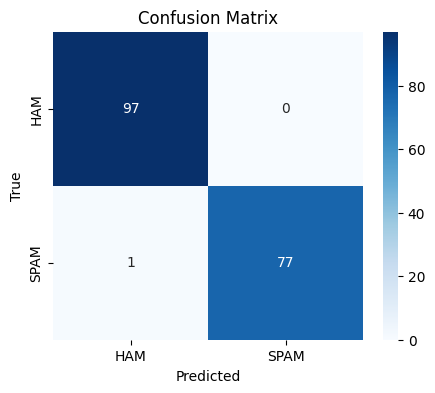

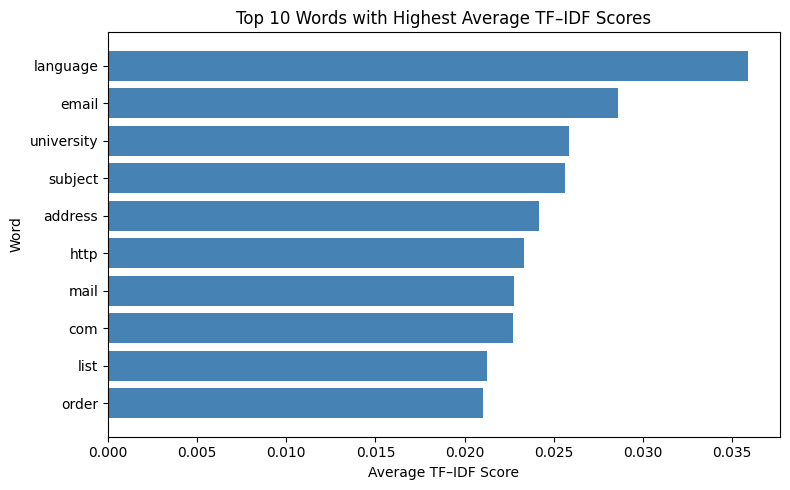

In [26]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

joblib.dump(nb, "spam_classifier_model.joblib")
joblib.dump(vectorizer, "tfidf_vectorizer.joblib")

y_pred = nb.predict(X_test_tfidf)



acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc*100:.2f}%\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

feature_names = np.array(vectorizer.get_feature_names_out())

tfidf_means = np.asarray(X_train_tfidf.mean(axis=0)).ravel()

df_tfidf = pd.DataFrame({
    'word': feature_names,
    'avg_tfidf': tfidf_means
})

top_words = df_tfidf.sort_values(by='avg_tfidf', ascending=False).head(10)


plt.figure(figsize=(8, 5))
plt.barh(top_words['word'][::-1], top_words['avg_tfidf'][::-1], color='steelblue')
plt.xlabel("Average TF–IDF Score")
plt.ylabel("Word")
plt.title("Top 10 Words with Highest Average TF–IDF Scores")
plt.tight_layout()
plt.show()

# 6. Fine Tune the Model

With the select model descibe the steps taken to acheve the best rusults possiable 


I dont think there is any fine tuning worth doing with a 99%+ accuracy. however, i can prove there is no data leakage. I clearly split the test data BEFORE training, and I only apply the vectorizer to the training data, as shown here:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    emails_df["clean_text"],
    emails_df["label_num"],
    test_size=0.2,
    random_state=1234,
    stratify=emails_df["label_num"]
)


X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 7. Present
In a customer faceing Document provide summery of finding and detail approach taken


# 8. Launch the Model System
Define your production run code, This should be self susficent and require only your model pramaters 


In [28]:
import re
import joblib

model = joblib.load("spam_classifier_model.joblib")
vectorizer = joblib.load("tfidf_vectorizer.joblib")

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def predict_message(message):
    cleaned = clean_text(message)
    X = vectorizer.transform([cleaned])
    pred = model.predict(X)[0]
    return "SPAM" if pred == 1 else "HAM"

example_spam = """
Congratulations! You've been selected for a limited-time offer.
Earn up to $1000 per week working from home. Click here to claim your reward!
"""

example_ham = """
Hey Alex, just wanted to confirm our meeting tomorrow at 10 AM.
"""


for label, msg in {
    "Example SPAM message": example_spam,
    "Example HAM message": example_ham
}.items():
    prediction = predict_message(msg)
    print(f"{label}:")
    print(f"   Prediction: {prediction}\n")

Example SPAM message:
   Prediction: SPAM

Example HAM message:
   Prediction: HAM

